In [2]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1).drop([0, 1,], axis = 0).reset_index(drop = True)
df.columns = ["Batch", "Batch Full Name"] + df.columns[2:].tolist()
# df = df[df.columns[:-9]

medium_df = df[["Batch", "Batch Full Name"] + df.columns[-9:].tolist()]
labels_df = df[["Batch", "Batch Full Name"] + [col for col in df.columns if "STR2K" in col]]
feats_df  = df[["Batch", "Batch Full Name"] + [col for col in df.columns if "Generic.Bioreactor" in col]]

medium_df.to_csv("./processed/n_step/medium_logged.csv", index = None)
labels_df.to_csv("./processed/n_step/labels.csv", index = None)
feats_df.to_csv("./processed/n_step/features.csv", index = None)

In [4]:
manual_df = pd.DataFrame(columns = ["Batch", "Airflow (Hi)", "Oxygen Flow (Hi)", "Baffles", "CO2 Sparger_Ring Sparger", "CO2 Sparger_Micro Sparger", "Feed A Rate", "Feed B Rate"])
manual_df["Airflow (Hi)"] = [0] * 5 + [1] * 6
manual_df["Batch"] = [f"FA{str(i + 1).zfill(3)}" for i in range(11)]
manual_df["Oxygen Flow (Hi)"] = [1] + [0] * 10
manual_df["Baffles"] = [0] * 7 + [1] * 4
manual_df["CO2 Sparger_Ring Sparger"] = [1] * 4 + [0] * 7
manual_df["CO2 Sparger_Micro Sparger"] = [0] * 4 + [1] * 7
manual_df["Feed A Rate"] = [3] * 3 + [0.3] * 8
manual_df["Feed B Rate"] = [0.3] * 3 + [0.36] * 8

manual_df.to_csv("./processed/n_step/metadata.csv")

manual_df

,Batch,Airflow (Hi),Oxygen Flow (Hi),Baffles,CO2 Sparger_Ring Sparger,CO2 Sparger_Micro Sparger,Feed A Rate,Feed B Rate
0,FA001,0,1,0,1,0,3.0,0.30
1,FA002,0,0,0,1,0,3.0,0.30
2,FA003,0,0,0,1,0,3.0,0.30
3,FA004,0,0,0,1,0,0.3,0.36
4,FA005,0,0,0,0,1,0.3,0.36
5,FA006,1,0,0,0,1,0.3,0.36
6,FA007,1,0,0,0,1,0.3,0.36
7,FA008,1,0,1,0,1,0.3,0.36
8,FA009,1,0,1,0,1,0.3,0.36
9,FA010,1,0,1,0,1,0.3,0.36


# Modelling

In [20]:
X = pd.merge(feats_df, manual_df, on = "Batch")
X = X[X.columns[2:]]

y = labels_df[labels_df.columns[5]]

In [21]:
labels_df.columns

Index(['Batch', 'Batch Full Name', 'STR2K_D05_2_1_PA_HPLC_Concentration',
       'STR2K_D06_2_1_PA_HPLC_Concentration',
       'STR2K_D07_2_1_PA_HPLC_Concentration',
       'STR2K_D08_2_1_PA_HPLC_Concentration',
       'STR2K_D09_2_1_PA_HPLC_Concentration',
       'STR2K_D10_2_1_PA_HPLC_Concentration',
       'STR2K_D11_2_1_PA_HPLC_Concentration',
       'STR2K_D12_2_1_PA_HPLC_Concentration',
       'STR2K_D13_2_1_PA_HPLC_Concentration',
       'STR2K_D14_4_1_PA_HPLC_Concentration'],
      dtype='object')

In [22]:
X

,Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty,Generic.Bioreactor.End Culture.Bolus base.Total Qty,Generic.Bioreactor.End Culture.Cell age at harvest,Generic.Bioreactor.End Culture.Culture duration,Generic.Bioreactor.End Culture.Final VCD,Generic.Bioreactor.End Culture.volume,Generic.Bioreactor.End Culture.PCV,Generic.Bioreactor.Equipment parameters at inoculation.Agitation,Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow,Generic.Bioreactor.Equipment parameters at inoculation.DO primary probe,...,Generic.Bioreactor.Pre-Inoculation.pCO2,Generic.Bioreactor.Pre-Inoculation.pH,Generic.Bioreactor.Pre-Inoculation.pO2,Airflow (Hi),Oxygen Flow (Hi),Baffles,CO2 Sparger_Ring Sparger,CO2 Sparger_Micro Sparger,Feed A Rate,Feed B Rate
0,2.462,21.128,36,331,14.3,1984.43,8.625,71.1,10.053,39.8,...,10,8,147.2,0,1,0,1,0,3.0,0.30
1,1.561,21.957,36,331,15.24,2008,8.208333,71.6,10.053,39.5,...,35.1,7.38,140.4,0,0,0,1,0,3.0,0.30
2,1.38,22.126,36,332,12.75,1979.6,8.291667,71,40.075,39.5,...,103.6,7.03,131.8,0,0,0,1,0,3.0,0.30
3,1.754,-1.295,36,333,10.86,1978.32,7.875,71.1,40.078,40.2,...,40.1,7.332,132.9,0,0,0,1,0,0.3,0.36
4,1.78,0.15,36,334,8.23,1975.59,7.041667,70.9,40.075,40,...,36.6,7.36,133.2,0,0,0,0,1,0.3,0.36
5,3.484,0.003,36,333,13.85,1980.34,8.583333,71.1,5.028,39.8,...,38.4,7.354,137.5,1,0,0,0,1,0.3,0.36
6,4.396,-2.723,36,332,15.95,1993.34,9.375,71.4,5.069,39.9,...,28.5,7.444,139.5,1,0,0,0,1,0.3,0.36
7,3.36,-1.333,36,331,13.79,1997.64,8.666667,71.1,5.028,40.6,...,58.2,7.22,136.3,1,0,1,0,1,0.3,0.36
8,3.63,-3.878,36,332,9.2,1981.82,8,71.5,25.059,39.2,...,31.4,7.409,137.1,1,0,1,0,1,0.3,0.36
9,4.292,-0.485,36,329,12.53,1985.82,8.166667,70.9,15.041,39,...,26.8,7.459,139.5,1,0,1,0,1,0.3,0.36


In [23]:
model = XGBRegressor()
X_copy = X.copy()
X_copy.drop([
    "Generic.Bioreactor.End Culture.Cell age at harvest",
    "Generic.Bioreactor.Equipment parameters at inoculation.Temperature"
], axis = 1, inplace = True)
X_copy = X_copy[[col for col in X_copy.columns if "End Culture" not in col]]
X_copy = X_copy - X_copy.min(axis = 0)
X_copy = X_copy / X_copy.max(axis = 0)
model.fit(X_copy.astype(float), y)

imp_df = pd.DataFrame({"Feature": X_copy.columns, "Importance": model.feature_importances_})
imp_df = imp_df.sort_values(by = "Importance", ascending = False).reset_index(drop = True)
imp_df["Feature"] = imp_df["Feature"].apply(lambda x: x.split(".")[-1])
imp_df.head(5)

,Feature,Importance
0,Air overlay flow,0.793518
1,DO primary probe,0.059743
2,Transfer volume,0.058086
3,pCO2,0.044948
4,Culture Start Volume,0.030764


In [24]:
y

0     2.61
1     2.45
2     2.54
3     2.56
4     2.36
5     2.61
6     3.08
7     2.89
8     2.56
9     2.59
10    2.61
Name: STR2K_D08_2_1_PA_HPLC_Concentration, dtype: object

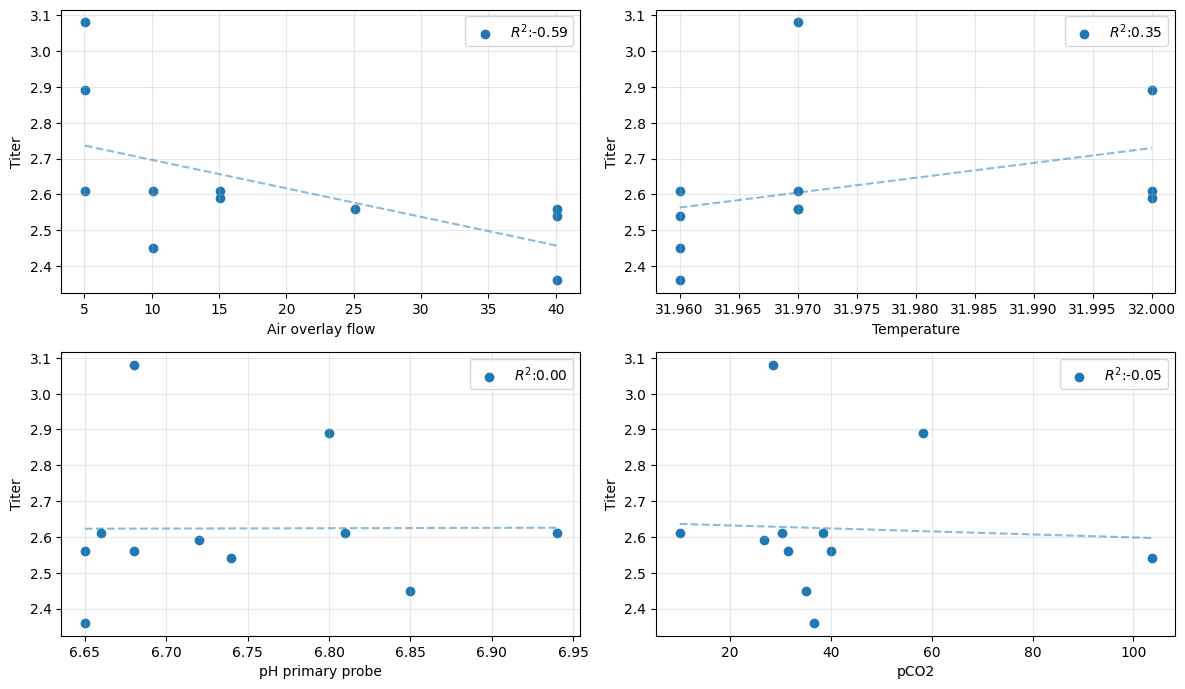

In [25]:
fig, axs = plt.subplots(2, 2, figsize = (12, 7))
feats = [
    "Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow", 
    "Generic.Bioreactor.Equipment parameters at inoculation.Temperature",
    "Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe",
    "Generic.Bioreactor.Pre-Inoculation.pCO2"
]

for i, feat in enumerate(feats):
    row_idx = i // 2
    col_idx = i % 2

    ax = axs[row_idx, col_idx]

    output = linregress(X[feat].tolist(), y.tolist())

    x_s = [X[feat].min(), X[feat].max()]
    y_s = [(output.slope * a) + output.intercept for a in x_s]

    ax.scatter(X[feat], y, label = f"$R^2$:{output.rvalue:.2f}")
    ax.plot(x_s, y_s, linestyle = '--', alpha = 0.5)
    ax.set_xlabel(feat.split(".")[-1])
    ax.set_ylabel("Titer")
    ax.grid(alpha = 0.3)
    ax.legend()
fig.tight_layout()

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

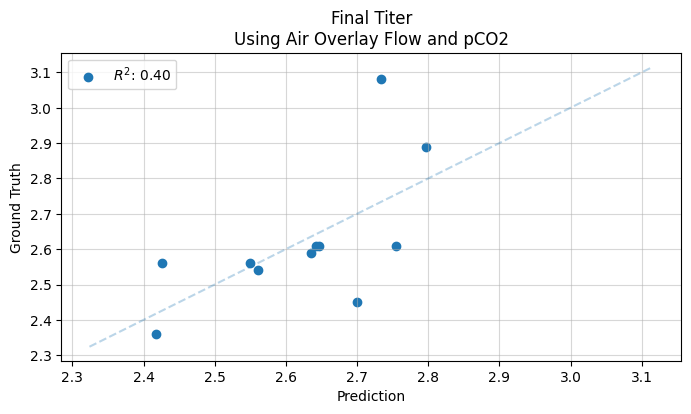

In [27]:
model = LinearRegression()

X_copy = X[[
    "Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow", 
    "Generic.Bioreactor.Pre-Inoculation.pCO2",
    # "Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe",
    # "Generic.Bioreactor.Equipment parameters at inoculation.Agitation"
]]
model.fit(X_copy, y)
preds = model.predict(X_copy)

score = r2_score(y, preds)

plt.figure(figsize = (8, 4))

plt.scatter(preds, y, label = f"$R^2$: {score:.2f}")
plt.plot([plt.ylim()[0].item(), plt.ylim()[1].item()], [plt.ylim()[0].item(), plt.ylim()[1].item()], alpha = 0.3, linestyle = '--')
plt.xlim((plt.ylim()[0].item(), plt.ylim()[1].item()))
plt.grid(alpha = 0.5)
plt.ylabel("Ground Truth")
plt.xlabel("Prediction")
plt.title("Final Titer\nUsing Air Overlay Flow and pCO2")
plt.legend()

plt.show()

0.0

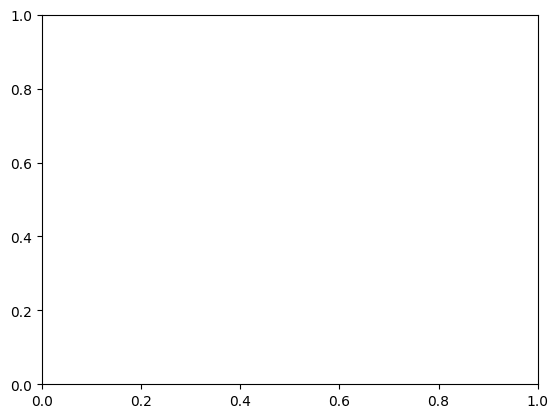

In [12]:
plt.ylim()[0].item()

In [13]:
model = LinearRegression()
X_copy = X.copy()
X_copy.drop("Generic.Bioreactor.End Culture.Cell age at harvest", axis = 1, inplace = True)
X_copy = X_copy[[col for col in X_copy.columns if "End Culture" not in col]]
X_copy = X_copy - X_copy.min(axis = 0)
X_copy = X_copy / X_copy.max(axis = 0)
model.fit(X_copy, y)

imp_df = pd.DataFrame({"Feature": X_copy.columns, "Importance": model.coef_})
imp_df = imp_df.sort_values(by = "Importance", ascending = False).reset_index(drop = True)
imp_df["Feature"] = imp_df["Feature"].apply(lambda x: x.split(".")[-1])
imp_df.head(5)

,Feature,Importance
0,Airflow (Hi),0.811950
1,Transfer volume,0.549602
2,Temperature,0.530638
3,pCO2,0.353554
4,CO2 Sparger_Ring Sparger,0.294311


In [95]:
X.columns

Index(['Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty',
       'Generic.Bioreactor.End Culture.Bolus base.Total Qty',
       'Generic.Bioreactor.End Culture.Cell age at harvest',
       'Generic.Bioreactor.End Culture.Culture duration',
       'Generic.Bioreactor.End Culture.Final VCD',
       'Generic.Bioreactor.End Culture.volume',
       'Generic.Bioreactor.End Culture.PCV',
       'Generic.Bioreactor.Equipment parameters at inoculation.Agitation',
       'Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow',
       'Generic.Bioreactor.Equipment parameters at inoculation.DO primary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.DO secondary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.Temperature',
       'Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.pH secondary probe',
       'Generic.Bioreactor.Inoculation.Cult

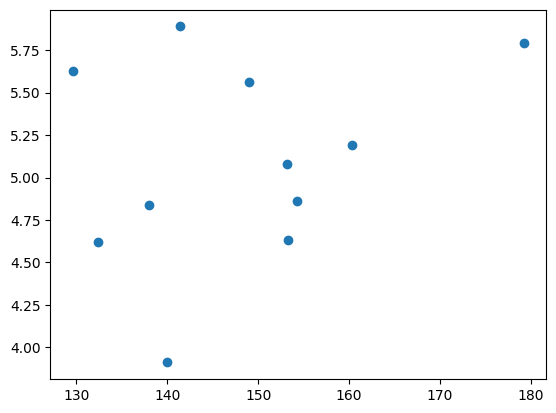

In [84]:
plt.scatter(X["Generic.Bioreactor.Inoculation.Transfer volume"], y)

In [75]:
X_copy.max()

Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty                         3.016
Generic.Bioreactor.End Culture.Bolus base.Total Qty                            26.004
Generic.Bioreactor.End Culture.Cell age at harvest                                  0
Generic.Bioreactor.End Culture.Culture duration                                     5
Generic.Bioreactor.End Culture.Final VCD                                         7.72
Generic.Bioreactor.End Culture.volume                                           32.41
Generic.Bioreactor.End Culture.PCV                                           2.333333
Generic.Bioreactor.Equipment parameters at inoculation.Agitation                  1.3
Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow         35.05
Generic.Bioreactor.Equipment parameters at inoculation.DO primary probe           1.6
Generic.Bioreactor.Equipment parameters at inoculation.DO secondary probe         1.6
Generic.Bioreactor.Equipment parameters at inoculation

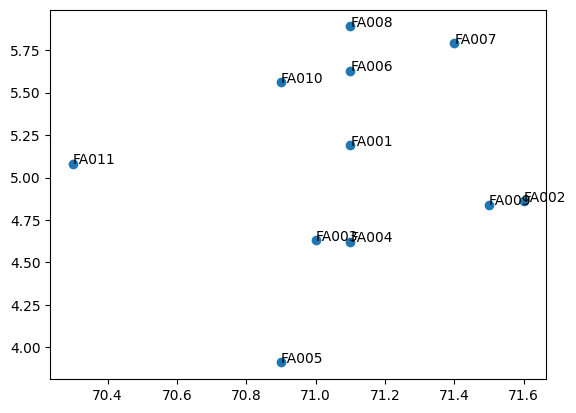

In [53]:
plt.scatter(X["Generic.Bioreactor.Equipment parameters at inoculation.Agitation"], y)

for i in range(df.shape[0]):
    plt.text(df["Generic.Bioreactor.Equipment parameters at inoculation.Agitation"][i], y[i], df[df.columns[0]][i])

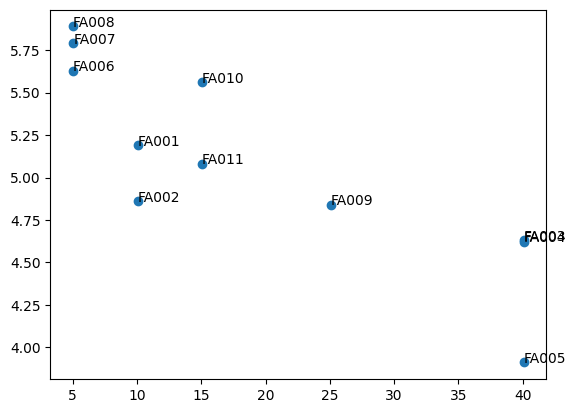

In [54]:
plt.scatter(X["Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow"], y)

for i in range(df.shape[0]):
    plt.text(df["Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow"][i], y[i], df[df.columns[0]][i])

In [3]:
# Bolus feed A and B variability might be interesting
# All other parameters are 0 at the first 3 day
# First 3 days are important for time series


# 

In [35]:
df2 = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 1, header = 1)
df2

,Run,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],IgG [g/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,49.646944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001_MCALR N-PROD 2000L_1003145,49.650000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN
2,FA001_MCALR N-PROD 2000L_1003145,49.746667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.047,NaN,NaN,NaN,-0.067209,NaN,NaN,NaN
3,FA001_MCALR N-PROD 2000L_1003145,49.750556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.0,NaN,NaN,NaN,NaN
4,FA001_MCALR N-PROD 2000L_1003145,49.751944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3322,FA011_MCALR N-PROD 2000L_1004660,377.617222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2665.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3323,FA011_MCALR N-PROD 2000L_1004660,377.621111,134.331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3324,FA011_MCALR N-PROD 2000L_1004660,377.623333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3325,FA011_MCALR N-PROD 2000L_1004660,377.626944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5893.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
df2.iloc[0]

Run                                                         FA001_MCALR N-PROD 2000L_1003145
Process Time [h]                                                                   49.646944
Ammonia [mg/L]                                                                           NaN
Bolus Feed A Daily Qty [kg]                                                              NaN
Bolus Glucose Daily Qty [kg]                                                             NaN
Bolus Feed B Daily Qty [kg]                                                              NaN
Glucose [mg/L]                                                                           NaN
Glutamate [mg/L]                                                                         NaN
Glutamine [mg/L]                                                                         NaN
IgG [g/L]                                                                                NaN
Lactate [mg/L]                                                        

In [22]:
df.columns

Index(['Batch', 'Batch Full Name', 'CNT_CAT_VAR_MES', 'CNT_SCALAR_MES',
       'CNT_TIME_DATA_MES', 'CNT_TIME_VAR_MES',
       'Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty',
       'Generic.Bioreactor.End Culture.Bolus base.Total Qty',
       'Generic.Bioreactor.End Culture.Cell age at harvest',
       'Generic.Bioreactor.End Culture.Culture duration',
       'Generic.Bioreactor.End Culture.Final VCD',
       'Generic.Bioreactor.End Culture.volume',
       'Generic.Bioreactor.End Culture.PCV',
       'Generic.Bioreactor.Equipment parameters at inoculation.Agitation',
       'Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow',
       'Generic.Bioreactor.Equipment parameters at inoculation.DO primary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.DO secondary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.Temperature',
       'Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe',
       

In [ ]:
# Take the primary and remove the secondary
# Percentage of oxygen in the bioreactor

In [5]:
clf = DecisionTreeRegressor()
X_cols = df.columns[2:-10]
clf.fit(df[X_cols], df[df.columns[-1]])

DecisionTreeRegressor()

In [6]:
pd.DataFrame({"Feature": X_cols, "Importance": clf.feature_importances_}).sort_values(by = "Importance", ascending = False).head()

,Feature,Importance
12,Generic.Bioreactor.Equipment parameters at ino...,0.781214
2,CNT_TIME_DATA_MES,0.143213
20,Generic.Bioreactor.Inoculation.Transfer volume,0.055723
19,Generic.Bioreactor.Inoculation.Medium equilibr...,0.016760
0,CNT_CAT_VAR_MES,0.001684


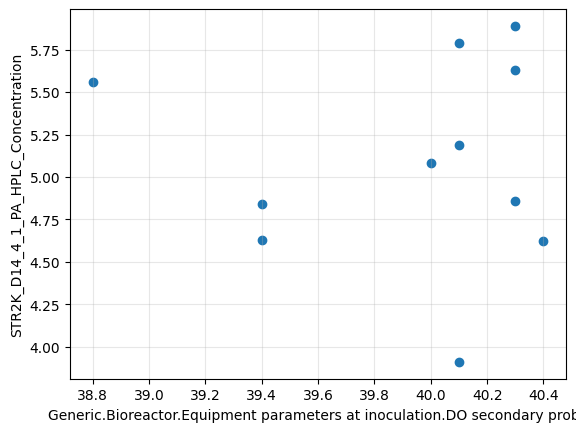

In [7]:
idx = 14
plt.scatter(df[X_cols[idx]], df[df.columns[-1]])
plt.xlabel(X_cols[idx])
plt.ylabel(df.columns[-1])
plt.grid(alpha = 0.3)
plt.show()

In [ ]:
# Air oxygen / CO2

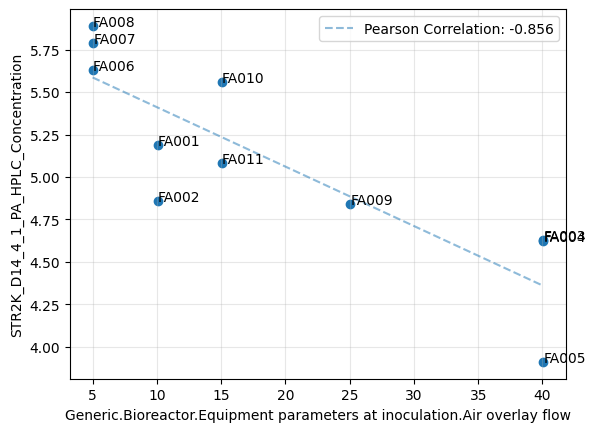

In [30]:
idx = 12

m,b = np.polyfit(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist(), 1)

plt.scatter(df[X_cols[idx]], df[df.columns[-1]])
corr = np.corrcoef(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist())[0, 1]
plt.plot([5, 40], [(5 * m) + b, (40 * m) + b], label = f"Pearson Correlation: {corr:.3f}", alpha = 0.5, linestyle = '--')
for i in range(df.shape[0]):
    plt.text(df[X_cols[idx]][i], df[df.columns[-1]][i], df[df.columns[0]][i])
plt.xlabel(X_cols[idx])
plt.ylabel(df.columns[-1])
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

In [ ]:
# Air overlay flow is decreased as air sparging is increased
# Process aimed to deal with high pCO2

In [33]:
df[[df.columns[0], X_cols[12], df.columns[-1]]].sort_values(by = df.columns[-1])

,Batch,Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow,STR2K_D14_4_1_PA_HPLC_Concentration
4,FA005,40.075,3.91
3,FA004,40.078,4.62
2,FA003,40.075,4.63
8,FA009,25.059,4.84
1,FA002,10.053,4.86
10,FA011,15.063,5.08
0,FA001,10.053,5.19
9,FA010,15.041,5.56
5,FA006,5.028,5.63
6,FA007,5.069,5.79


In [19]:
def get_corr(idx):    
    corr = np.corrcoef(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist())[0, 1]
    return corr
X_ordered = [(get_corr(idx), idx) for idx in X_cols]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

/tmp/ipykernel_1040918/2120184185.py:13: RankWarning: Polyfit may be poorly conditioned
  m,b = np.polyfit(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist(), 1)
/tmp/ipykernel_1040918/2120184185.py:13: RankWarning: Polyfit may be poorly conditioned
  m,b = np.polyfit(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist(), 1)
/tmp/ipykernel_1040918/2120184185.py:13: RankWarning: Polyfit may be poorly conditioned
  m,b = np.polyfit(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist(), 1)


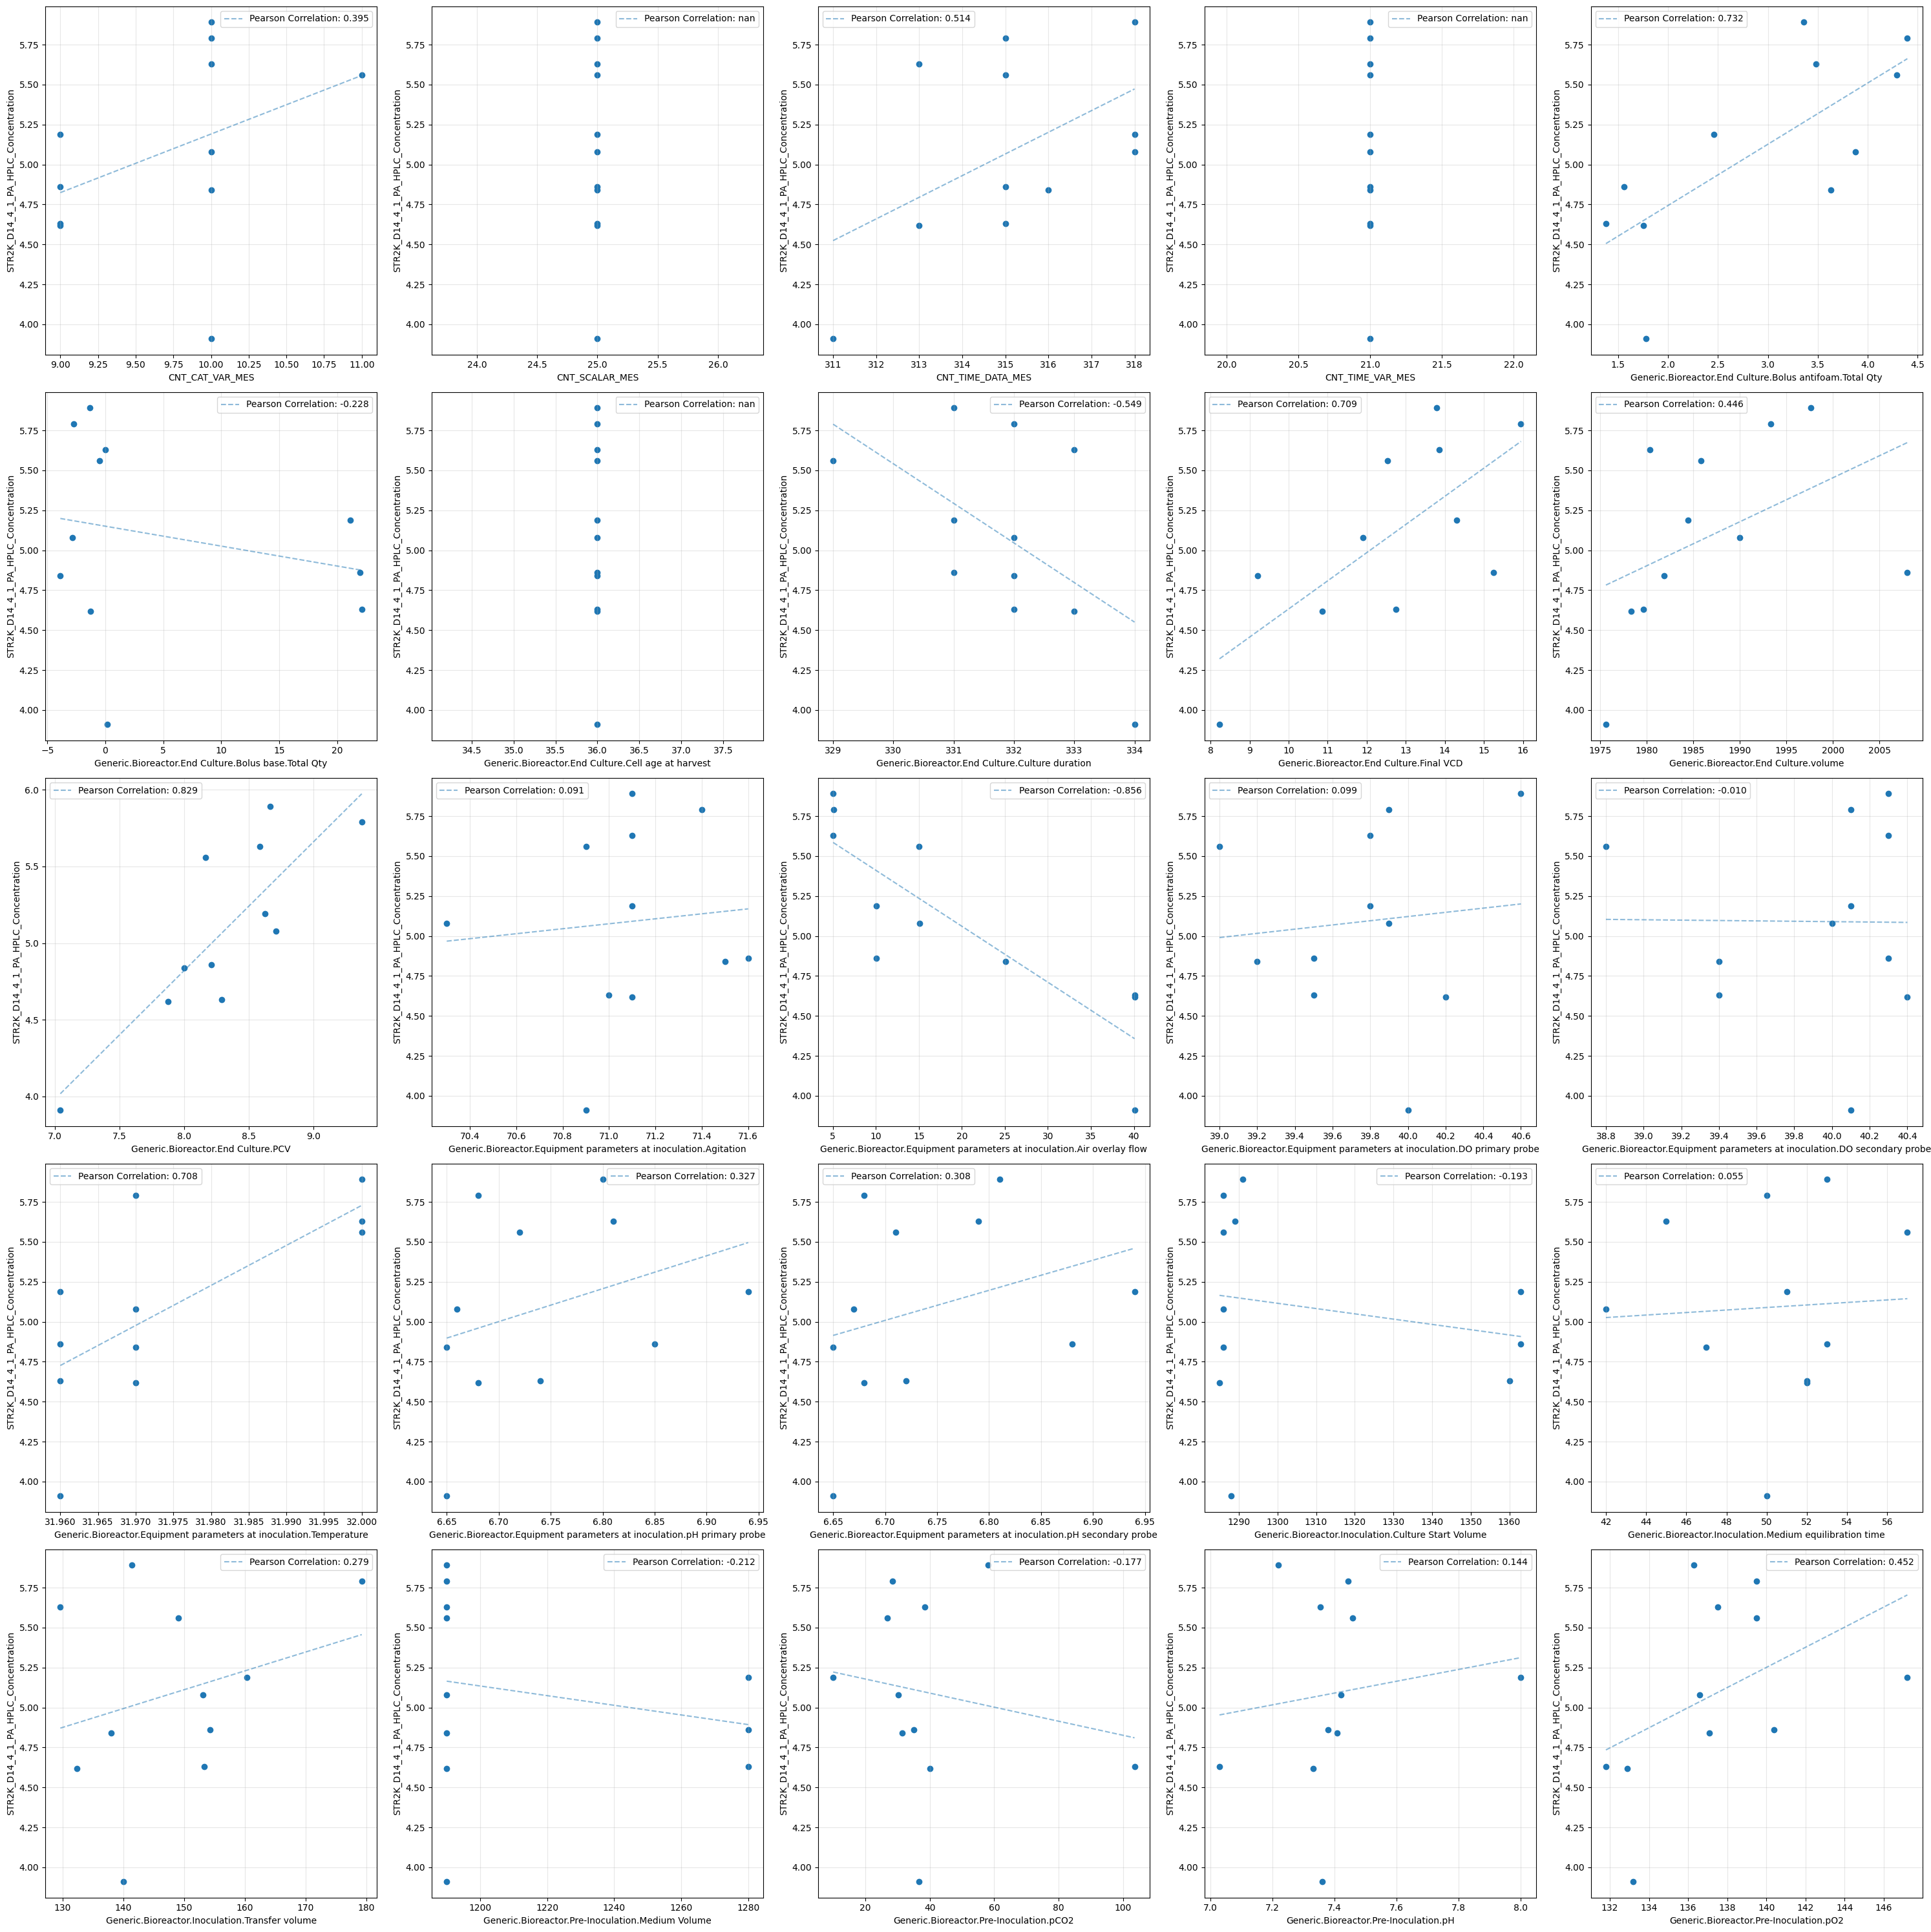

In [21]:
fig, axs = plt.subplots(5, 5, figsize = (30, 30))

# def get_corr(idx):    
#     m,b = np.polyfit(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist(), 1)
# X_ordered = [(get_corr(idx), idx) for idx in X_cols]

for idx in range(X_cols.shape[0]):
    row_idx = idx // 5
    col_idx = idx % 5
    ax = axs[row_idx][col_idx]

    ax.scatter(df[X_cols[idx]], df[df.columns[-1]])
    m,b = np.polyfit(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist(), 1)
    corr = np.corrcoef(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist())[0, 1]
    min_val = df[X_cols[idx]].min()
    max_val = df[X_cols[idx]].max()
    ax.plot([min_val, max_val], [(min_val * m) + b, (max_val * m) + b], label = f"Pearson Correlation: {corr:.3f}", alpha = 0.5, linestyle = '--')
    ax.set_xlabel(X_cols[idx])
    ax.set_ylabel(df.columns[-1])
    ax.grid(alpha = 0.3)
    ax.legend()

fig.tight_layout()

In [ ]:
idx = 12

m,b = np.polyfit(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist(), 1)

plt.scatter(df[X_cols[idx]], df[df.columns[-1]])
corr = np.corrcoef(df[X_cols[idx]].tolist(), df[df.columns[-1]].tolist())[0, 1]
plt.plot([5, 40], [(5 * m) + b, (40 * m) + b], label = f"Pearson Correlation: {corr:.3f}", alpha = 0.5, linestyle = '--')
plt.xlabel(X_cols[idx])
plt.ylabel(df.columns[-1])
plt.grid(alpha = 0.3)
plt.legend()
plt.show()